# Agent Communication Matrix - Vector Search Demo

This notebook demonstrates vector search against the Oracle database using embedded queries.

In [5]:
import os
import sys
import time
import requests
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv
import oracledb

load_dotenv()
project_root = Path().cwd().parent
sys.path.insert(0, str(project_root))

## Step 1: Initialize Connections

In [6]:
# Oracle connection
db_user = os.getenv('DB_USER', 'agentuser')
db_password = os.getenv('DB_PASS', 'AgentPass_123')
db_dsn = os.getenv('DB_DSN', 'localhost:1521/FREEPDB1')

conn = oracledb.connect(
    user=db_user,
    password=db_password,
    dsn=db_dsn
)
print("\u2713 Connected to Oracle")

# Ollama connection
ollama_host = os.getenv('OLLAMA_URL', 'http://localhost:11434')
ollama_model = os.getenv('EMBED_MODEL', 'nomic-embed-text')
print(f"\u2713 Configured Ollama: {ollama_model}")

✓ Connected to Oracle
✓ Configured Ollama: nomic-embed-text


## Step 2: Define Search Function

In [7]:
def vector_search(query_text, top_k=5):
    results = {
        'query': query_text,
        'embedding_time': 0,
        'search_time': 0,
        'matches': []
    }
    
    # Step 1: Generate embedding
    try:
        emb_start = time.time()
        response = requests.post(
            f"{ollama_host}/api/embed",
            json={"model": ollama_model, "input": query_text},
            timeout=30
        )
        results['embedding_time'] = (time.time() - emb_start) * 1000
        
        if response.status_code != 200:
            print(f"Error generating embedding: {response.status_code}")
            return results
        
        embedding = response.json()['embeddings'][0]
        embedding_str = ','.join(str(x) for x in embedding)
        vec_text = f'[{embedding_str}]'

        # Step 2: Vector search in Oracle (use bind variable for long string)
        search_start = time.time()
        with conn.cursor() as cursor:
            sql = f"""
                SELECT id, chunk_text, 
                       VECTOR_DISTANCE(embedding, TO_VECTOR(:vec)) as distance
                FROM kb_chunks
                ORDER BY distance
                FETCH FIRST {top_k} ROWS ONLY
            """
            # Ensure large embedding string is sent as CLOB to avoid literal length limits
            try:
                cursor.setinputsizes(vec=oracledb.DB_TYPE_CLOB)
            except Exception:
                pass
            cursor.execute(sql, vec=vec_text)
            rows = cursor.fetchall()
            results['search_time'] = (time.time() - search_start) * 1000
            
            for row_id, text, distance in rows:
                # `chunk_text` may be returned as a DB LOB object; read it if so.
                try:
                    if hasattr(text, 'read'):
                        txt = text.read()
                    else:
                        txt = str(text)
                except Exception:
                    txt = str(text)

                results['matches'].append({
                    'id': row_id,
                    'text': txt[:100],
                    'distance': distance
                })
    
    except Exception as e:
        print(f"Search error: {e}")
    
    return results

print("✓ Vector search function defined")

✓ Vector search function defined


## Step 3: Run Sample Searches

In [8]:
queries = [
    "machine learning algorithms",
    "data processing pipeline",
    "neural network architecture"
]

all_results = []

for query in queries:
    print(f"\nSearching for: '{query}'")
    results = vector_search(query, top_k=3)
    all_results.append(results)
    
    print(f"  Embedding: {results['embedding_time']:.1f}ms")
    print(f"  Search: {results['search_time']:.1f}ms")
    print(f"  Total: {results['embedding_time'] + results['search_time']:.1f}ms")
    print(f"  Matches: {len(results['matches'])}")


Searching for: 'machine learning algorithms'
  Embedding: 72.3ms
  Search: 40.9ms
  Total: 113.3ms
  Matches: 3

Searching for: 'data processing pipeline'
  Embedding: 68.1ms
  Search: 1.9ms
  Total: 70.0ms
  Matches: 3

Searching for: 'neural network architecture'
  Embedding: 91.1ms
  Search: 1.9ms
  Total: 93.0ms
  Matches: 3


## Step 4: Display Results

In [9]:
for results in all_results:
    print(f"\n{'='*60}")
    print(f"Query: {results['query']}")
    print(f"{'='*60}")
    
    df = pd.DataFrame(results['matches'])
    if len(df) > 0:
        df = df[['id', 'text', 'distance']]
        df.columns = ['ID', 'Text Preview', 'Distance']
        display(df)
    else:
        print("  No matches found")


Query: machine learning algorithms


,ID,Text Preview,Distance
0,97,"When working with machine learning, engineers ...",0.324892
1,82,Understanding machine learning requires deep k...,0.325886
2,15,Modern systems implementing machine learning o...,0.346384



Query: data processing pipeline


,ID,Text Preview,Distance
0,79,The relationship between machine learning and ...,0.419598
1,13,Understanding natural language processing requ...,0.423317
2,18,"When working with natural language processing,...",0.437420



Query: neural network architecture


,ID,Text Preview,Distance
0,53,Modern systems implementing natural language p...,0.413695
1,14,Modern systems implementing agent memory often...,0.433833
2,15,Modern systems implementing machine learning o...,0.437218


## Step 5: Latency Analysis

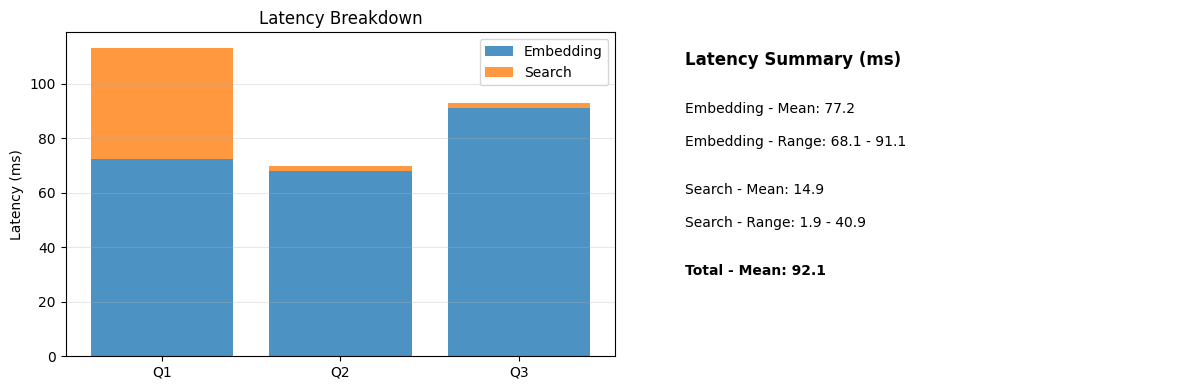


Embedding dominates: 5.2x slower than search


In [10]:
import matplotlib.pyplot as plt
import numpy as np

embedding_times = [r['embedding_time'] for r in all_results]
search_times = [r['search_time'] for r in all_results]
total_times = [e + s for e, s in zip(embedding_times, search_times)]

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Stacked bar chart
x = np.arange(len(queries))
ax1.bar(x, embedding_times, label='Embedding', alpha=0.8)
ax1.bar(x, search_times, bottom=embedding_times, label='Search', alpha=0.8)
ax1.set_ylabel('Latency (ms)')
ax1.set_title('Latency Breakdown')
ax1.set_xticks(x)
ax1.set_xticklabels([f"Q{i+1}" for i in range(len(queries))])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Summary stats
ax2.text(0.1, 0.9, "Latency Summary (ms)", fontsize=12, fontweight='bold', transform=ax2.transAxes)
ax2.text(0.1, 0.75, f"Embedding - Mean: {np.mean(embedding_times):.1f}", transform=ax2.transAxes)
ax2.text(0.1, 0.65, f"Embedding - Range: {np.min(embedding_times):.1f} - {np.max(embedding_times):.1f}", transform=ax2.transAxes)
ax2.text(0.1, 0.50, f"Search - Mean: {np.mean(search_times):.1f}", transform=ax2.transAxes)
ax2.text(0.1, 0.40, f"Search - Range: {np.min(search_times):.1f} - {np.max(search_times):.1f}", transform=ax2.transAxes)
ax2.text(0.1, 0.25, f"Total - Mean: {np.mean(total_times):.1f}", transform=ax2.transAxes, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

print(f"\nEmbedding dominates: {np.mean(embedding_times) / np.mean(search_times):.1f}x slower than search")